In [ ]:
import pandas as pd
movies = pd.read_csv('files/3/movies.csv')
ratings = pd.read_csv('files/3/ratings.csv')

data = pd.merge(ratings, movies, on='movieId')
data = data.head(200000)
print('movies: ')
print(movies.head())
print('data: ')
print(data.head())
print('data: ')
print(data.head())

In [9]:
data.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [10]:
data.describe(include='all')

,userId,movieId,rating,timestamp,title,genres
count,3.200020e+07,3.200020e+07,3.200020e+07,3.200020e+07,32000204,32000204
unique,NaN,NaN,NaN,NaN,84239,1783
top,NaN,NaN,NaN,NaN,"Shawshank Redemption, The (1994)",Drama
freq,NaN,NaN,NaN,NaN,102929,2256325
mean,1.002785e+05,2.931861e+04,3.540396e+00,1.275241e+09,NaN,NaN
std,5.794905e+04,5.095816e+04,1.058986e+00,2.561630e+08,NaN,NaN
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08,NaN,NaN
25%,5.005300e+04,1.233000e+03,3.000000e+00,1.051012e+09,NaN,NaN
50%,1.002970e+05,3.452000e+03,3.500000e+00,1.272622e+09,NaN,NaN
75%,1.504510e+05,4.419900e+04,4.000000e+00,1.503158e+09,NaN,NaN


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = data[['userId', 'movieId']]
y = data['rating']

# Разделение данных на тренировочные и тестовые
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

import numpy as np
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (140000, 2)
Размер тестовой выборки: (60000, 2)


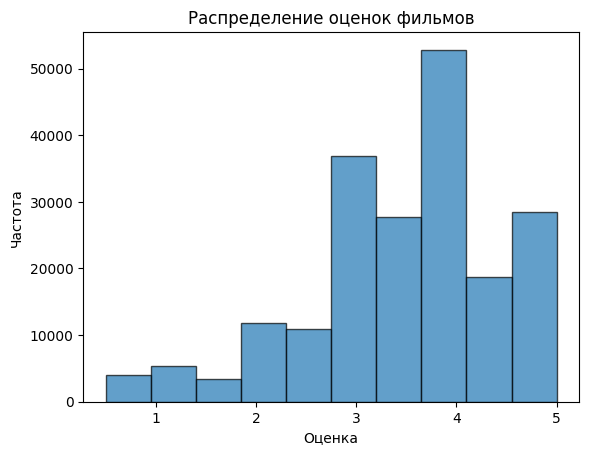

In [13]:
import matplotlib.pyplot as plt

plt.hist(data['rating'], bins=10, edgecolor='black', alpha=0.7)
plt.title('Распределение оценок фильмов')
plt.xlabel('Оценка')
plt.ylabel('Частота')
plt.show()


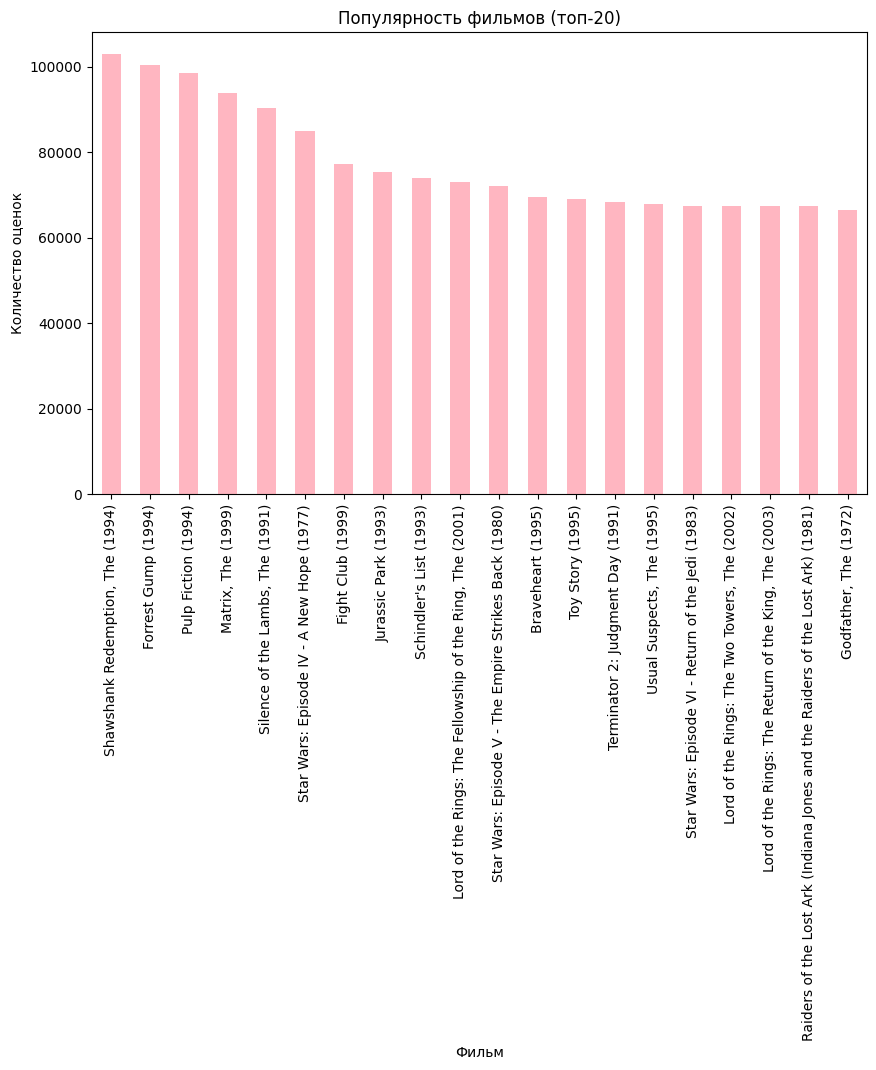

In [19]:
movie_counts = data['title'].value_counts().head(20)  # Топ-20 популярных фильмов
plt.figure(figsize=(10, 6))
movie_counts.plot(kind='bar', color='lightpink')
plt.title('Популярность фильмов (топ-20)')
plt.xlabel('Фильм')
plt.ylabel('Количество оценок')
plt.show()


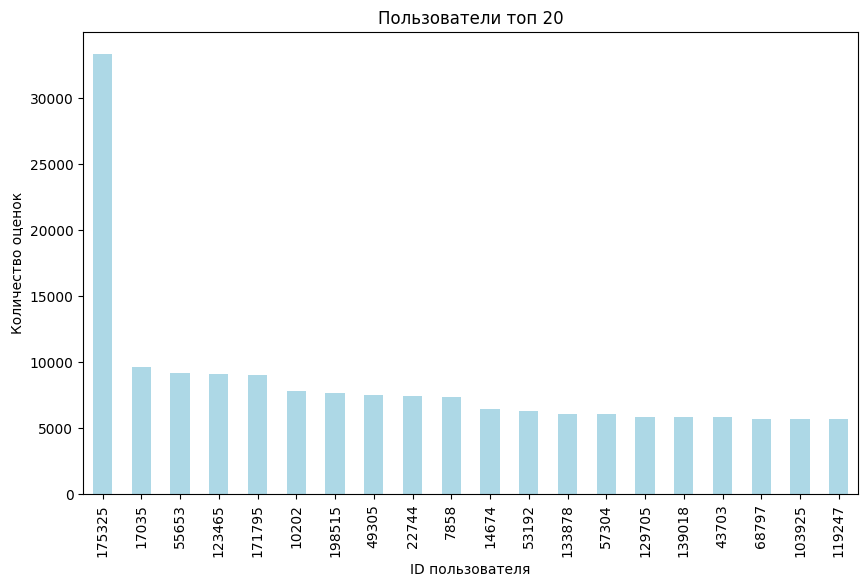

In [23]:
user_counts = data['userId'].value_counts().head(20)  # Топ-20 популярных фильмов
plt.figure(figsize=(10, 6))
user_counts.plot(kind='bar', color='lightblue')
plt.title('Пользователи топ 20')
plt.xlabel('ID пользователя')
plt.ylabel('Количество оценок')
plt.show()


In [36]:
# 1. RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(n_estimators=300, random_state=42)

random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R^2 Score: {r2}")

Mean Squared Error (MSE): 0.08312976286244465
Mean Absolute Error (MAE): 0.20392476766604037
R^2 Score: -0.029016910802391216


In [37]:
# 2. GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = GradientBoostingRegressor(n_estimators=300, random_state=42)

gradient_boosting.fit(X_train, y_train)

y_pred_gb = gradient_boosting.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Mean Squared Error (MSE): {mse_gb}")
print(f"Mean Absolute Error (MAE): {mae_gb}")
print(f"R^2 Score: {r2_gb}")

Mean Squared Error (MSE): 0.06950389006891276
Mean Absolute Error (MAE): 0.1903481258103069
R^2 Score: 0.13965015916372425


In [38]:
#3 AdaBoostRegressor
from sklearn.ensemble import AdaBoostRegressor

ada_boost = AdaBoostRegressor(n_estimators=300, random_state=42)
ada_boost.fit(X_train, y_train)
y_pred_ab = ada_boost.predict(X_test)

mse_ab = mean_squared_error(y_test, y_pred_ab)
mae_ab = mean_absolute_error(y_test, y_pred_ab)
r2_ab = r2_score(y_test, y_pred_ab)

print(f"Mean Squared Error (MSE): {mse_ab}")
print(f"Mean Absolute Error (MAE): {mae_ab}")
print(f"R^2 Score: {r2_ab}")

Mean Squared Error (MSE): 0.08397716971147734
Mean Absolute Error (MAE): 0.2236711006333749
R^2 Score: -0.03950648695368231


In [ ]:
#4 ExtraTreesRegressor
from sklearn.ensemble import ExtraTreesRegressor
extra_trees = ExtraTreesRegressor(n_estimators=300, random_state=42)
extra_trees.fit(X_train, y_train)
y_pred_et = extra_trees.predict(X_test)

mse_et = mean_squared_error(y_test, y_pred_et)
mae_et = mean_absolute_error(y_test, y_pred_et)
r2_et = r2_score(y_test, y_pred_et)

print(f"Mean Squared Error (MSE): {mse_et}")
print(f"Mean Absolute Error (MAE): {mae_et}")
print(f"R^2 Score: {r2_et}")

Mean Squared Error (MSE): 0.08733248703912937
Mean Absolute Error (MAE): 0.2082467671866511
R^2 Score: -0.08104008638154792


In [18]:
# 5. VotingRegressor
from sklearn.ensemble import VotingRegressor

voting_regressor = VotingRegressor(estimators=[
    ('rf', random_forest),
    ('gb', gradient_boosting),
    ('ab', ada_boost),
    ('et', extra_trees)
])
voting_regressor.fit(X_train, y_train)
y_pred_vr = voting_regressor.predict(X_test)

mse_vr = mean_squared_error(y_test, y_pred_vr)
mae_vr = mean_absolute_error(y_test, y_pred_vr)
r2_vr = r2_score(y_test, y_pred_vr)

print(f"Mean Squared Error (MSE): {mse_vr}")
print(f"Mean Absolute Error (MAE): {mae_vr}")
print(f"R^2 Score: {r2_vr}")

Mean Squared Error (MSE): 0.07138203003780187
Mean Absolute Error (MAE): 0.19561228600903924
R^2 Score: 0.11640171333285243


In [19]:
# 6. BaggingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
bagging_regressor = BaggingRegressor(n_estimators=50, random_state=42)

bagging_regressor.fit(X_train, y_train)
y_pred_br = bagging_regressor.predict(X_test)

mse_br = mean_squared_error(y_test, y_pred_br)
mae_br = mean_absolute_error(y_test, y_pred_br)
r2_br = r2_score(y_test, y_pred_br)

print(f"Mean Squared Error (MSE): {mse_br}")
print(f"Mean Absolute Error (MAE): {mae_br}")
print(f"R^2 Score: {r2_br}")

Mean Squared Error (MSE): 0.08381687131293555
Mean Absolute Error (MAE): 0.20475566636515377
R^2 Score: -0.03752224259649606


In [20]:
# 7. StackingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
stacking_regressor = StackingRegressor(estimators=[
    ('rf', random_forest),
    ('gb', gradient_boosting),
    ('ab', ada_boost)
], final_estimator=LinearRegression())

stacking_regressor.fit(X_train, y_train)
y_pred_sr = bagging_regressor.predict(X_test)

mse_sr = mean_squared_error(y_test, y_pred_sr)
mae_sr = mean_absolute_error(y_test, y_pred_sr)
r2_sr = r2_score(y_test, y_pred_sr)

print(f"Mean Squared Error (MSE): {mse_sr}")
print(f"Mean Absolute Error (MAE): {mae_sr}")
print(f"R^2 Score: {r2_sr}")

Mean Squared Error (MSE): 0.08381687131293555
Mean Absolute Error (MAE): 0.20475566636515377
R^2 Score: -0.03752224259649606


C:\Users\angel\AppData\Local\Temp\ipykernel_21112\2035743546.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models_mse.keys()), y=list(models_mse.values()), palette='viridis')


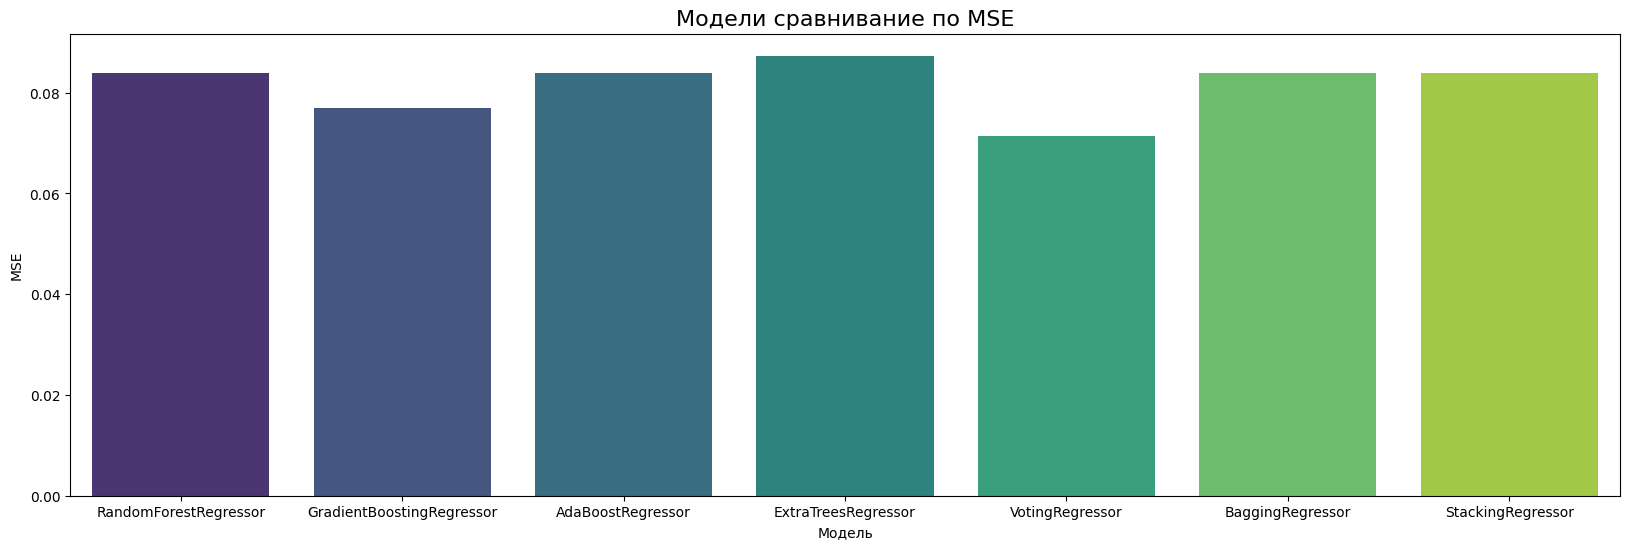

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

models_mse = {
    'RandomForestRegressor': mse,
    'GradientBoostingRegressor': mse_gb,
    'AdaBoostRegressor': mse_ab,
    'ExtraTreesRegressor': mse_et,
    'VotingRegressor': mse_vr,
    'BaggingRegressor': mse_br,
    'StackingRegressor': mse_sr
}

plt.figure(figsize=(20,6))
sns.barplot(x=list(models_mse.keys()), y=list(models_mse.values()), palette='viridis')
plt.title('Модели сравнивание по MSE', fontsize=16)
plt.xlabel("Модель", fontsize=10)
plt.ylabel("MSE", fontsize=10)
plt.show()

C:\Users\angel\AppData\Local\Temp\ipykernel_21112\2101927882.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models_mae.keys()), y=list(models_mae.values()), palette='magma')


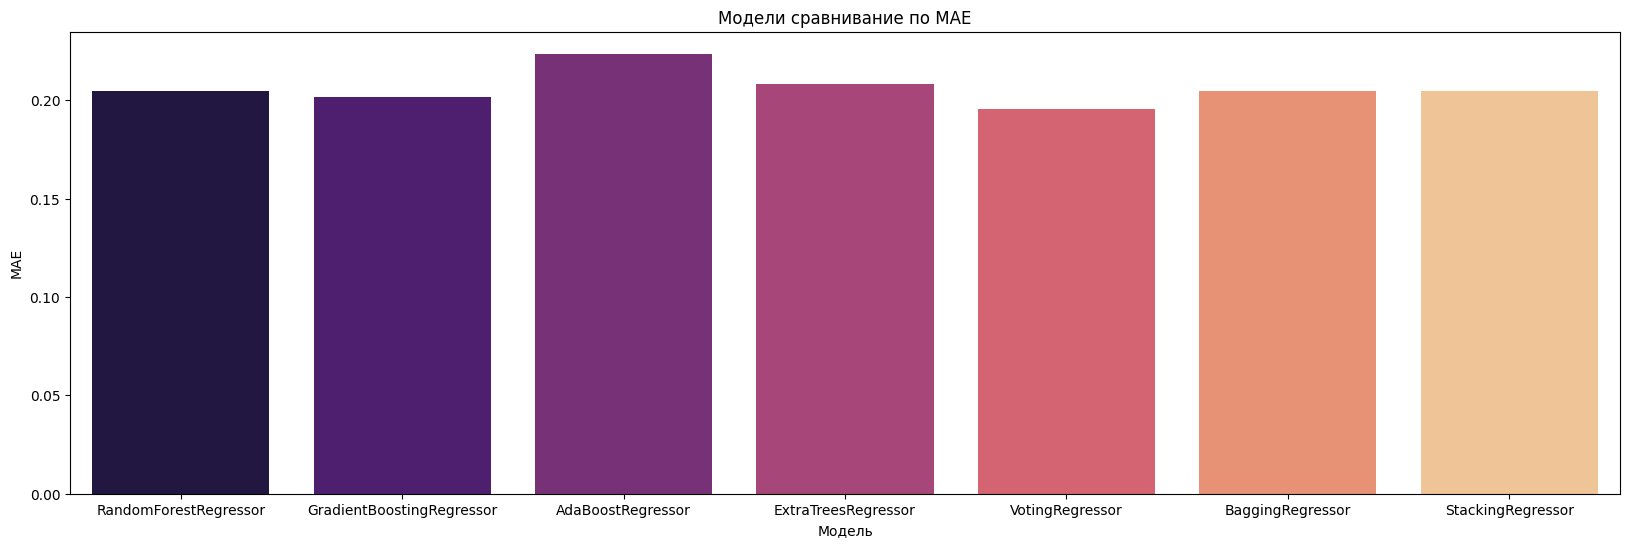

In [23]:
models_mae = {
    'RandomForestRegressor': mae,
    'GradientBoostingRegressor': mae_gb,
    'AdaBoostRegressor': mae_ab,
    'ExtraTreesRegressor': mae_et,
    'VotingRegressor': mae_vr,
    'BaggingRegressor': mae_br,
    'StackingRegressor': mae_sr
}

plt.figure(figsize=(20,6))
sns.barplot(x=list(models_mae.keys()), y=list(models_mae.values()), palette='magma')
plt.title('Модели сравнивание по MAE')
plt.xlabel("Модель")
plt.ylabel("MAE")
plt.show()

C:\Users\angel\AppData\Local\Temp\ipykernel_21112\1427790603.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models_r2.keys()), y=list(models_r2.values()), palette='pastel')


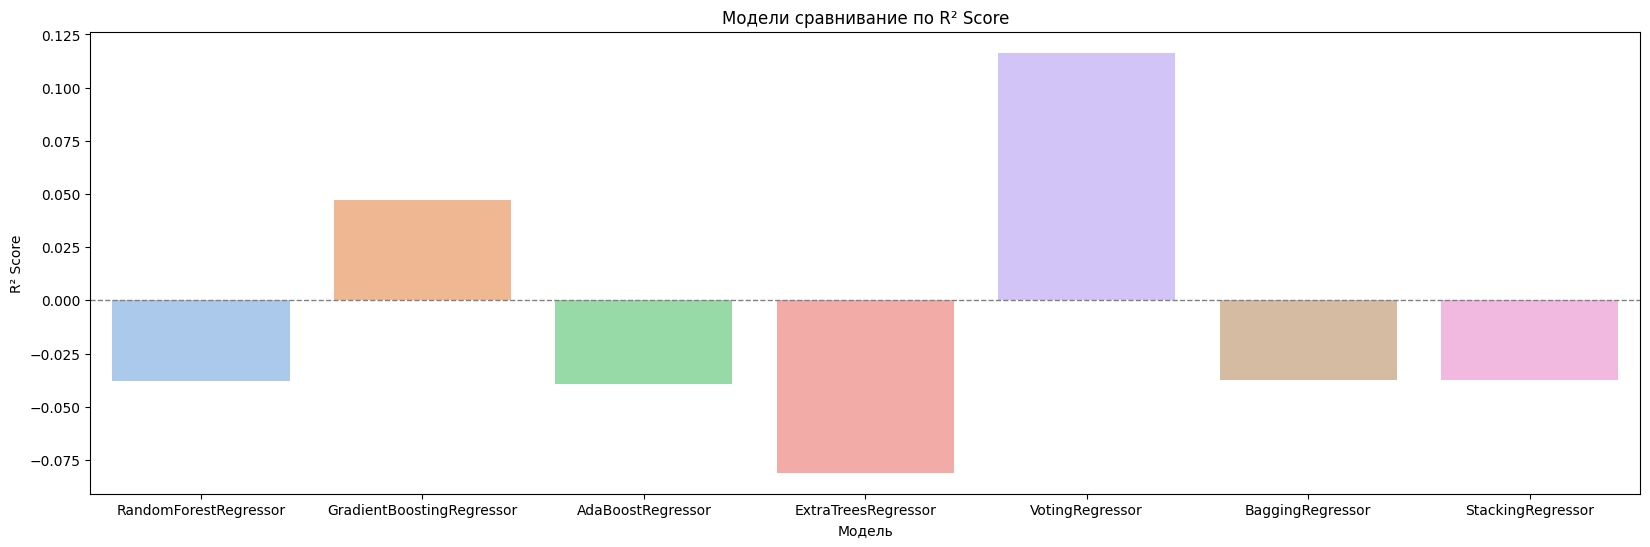

In [34]:
models_r2 = {
    'RandomForestRegressor': r2,
    'GradientBoostingRegressor': r2_gb,
    'AdaBoostRegressor': r2_ab,
    'ExtraTreesRegressor': r2_et,
    'VotingRegressor': r2_vr,
    'BaggingRegressor': r2_br,
    'StackingRegressor': r2_sr
}

plt.figure(figsize=(20,6))
sns.barplot(x=list(models_r2.keys()), y=list(models_r2.values()), palette='pastel')
plt.title('Модели сравнивание по R² Score')
plt.xlabel("Модель")
plt.ylabel("R² Score")
#plt.ylim(-1, 1)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.show()
